# Обучение моделей

## Импорт библиотек

In [1]:
import os
import sys
from pathlib import Path
import json
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import (
    StandardScaler,
    FunctionTransformer,
    TargetEncoder,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    RocCurveDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import optuna

import shap

import joblib

# Добавляем путь к src
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.data_loader import DataLoader
from src.preprocess import Preprocessor
from src.features import FeatureEngineer

## Загрузка данных

In [2]:
# Загружаем переменные из .env
load_dotenv()

# Загружаем датасет
DATASET_PATH = os.getenv("DATA_PATH")
KAGGLE_DS = os.getenv("KAGGLE_DATASET")

df = DataLoader.load(DATASET_PATH, KAGGLE_DS)

In [3]:
df.head()

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153440,0.930628,4,0.228103,0


## Разделение на выборки

In [4]:
# Разделение на признаки и целевую переменную
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (32581, 28), y shape: (32581,)


In [5]:
# Разделение на обучающую и тестовую выборки (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} записей")
print(f"Test:  {X_test.shape[0]} записей")
print(f"Доля дефолтов в train: {y_train.mean():.4f}")
print(f"Доля дефолтов в test:  {y_test.mean():.4f}")

Train: 26064 записей
Test:  6517 записей
Доля дефолтов в train: 0.2182
Доля дефолтов в test:  0.2182


## Обучение моделей

### LogisticRegression

In [6]:
# Определение групп признаков для логистической регрессии

# Сильно скошенные -> логарифм + масштабирование
lr_log_cols = ["person_income", "loan_amnt", "other_debt"]

# Остальные числовые -> масштабирование (включая loan_term_months и past_delinquencies)
lr_num_cols = [
    "person_age", "person_emp_length", "loan_int_rate", "loan_percent_income",
    "cb_person_cred_hist_length", "debt_to_income_ratio", "open_accounts",
    "credit_utilization_ratio", "income_debt_balance",
    "is_high_debt", "is_high_loan_pct", "is_high_rate", "emp_length_missing",
    "loan_term_months", "past_delinquencies"
]

# Порядковый признак loan_grade -> OrdinalEncoder с явными категориями
grade_categories = [["A", "B", "C", "D", "E", "F", "G"]]
grade_encoder = OrdinalEncoder(
    categories=grade_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Бинарные строковые -> OneHotEncoder с drop='if_binary'
lr_onehot_binary_cols = ["cb_person_default_on_file", "gender"]

# Низкокардинальные строковые (2–10 уникальных) -> OneHotEncoder
lr_onehot_cols = [
    "person_home_ownership", "loan_intent", "marital_status",
    "education_level", "employment_type"
]

# Средне- и высококардинальные -> TargetEncoder
lr_target_cols = ["city", "grade_ownership", "default_grade"]

In [7]:
# Сборка ColumnTransformer
lr_preprocessor = ColumnTransformer([
    ("log_num", Pipeline([
        ("log", FunctionTransformer(np.log1p, validate=True)),
        ("scale", StandardScaler())
    ]), lr_log_cols),
    ("num", StandardScaler(), lr_num_cols),
    ("grade_ordinal", grade_encoder, ["loan_grade"]),
    ("onehot_binary", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), lr_onehot_binary_cols),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), lr_onehot_cols),
    ("target", TargetEncoder(target_type="binary", smooth=1.0), lr_target_cols)
])

In [8]:
# Полный пайплайн для логистической регрессии
lr_pipeline = Pipeline([
    ("basic_preprocessing", Preprocessor()),
    ("feature_engineer", FeatureEngineer(include_weak=False)),
    ("custom_preprocessing", lr_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

In [9]:
# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print(f"LogisticRegression CV ROC-AUC: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")

LogisticRegression CV ROC-AUC: 0.8834 (+/- 0.0026)


### RandomForestClassifier

In [10]:
# Определение групп признаков для Random Forest

# Числовые признаки (без масштабирования, passthrough)
rf_num_cols = [
    "person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length",
    "debt_to_income_ratio", "open_accounts", "credit_utilization_ratio",
    "income_debt_balance", "is_high_debt", "is_high_loan_pct", "is_high_rate",
    "emp_length_missing", "loan_term_months", "past_delinquencies"
]

# Порядковый признак loan_grade -> OrdinalEncoder с явными категориями
grade_categories = [["A", "B", "C", "D", "E", "F", "G"]]
grade_encoder = OrdinalEncoder(
    categories=grade_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Бинарные строковые -> OneHotEncoder с drop='if_binary'
rf_onehot_binary_cols = ["cb_person_default_on_file", "gender"]

# Низкокардинальные строковые (2–10 уникальных) -> OneHotEncoder
rf_onehot_cols = [
    "person_home_ownership", "loan_intent", "marital_status",
    "education_level", "employment_type"
]

# Средне- и высококардинальные -> OneHotEncoder
rf_high_card_cols = ["city", "grade_ownership", "default_grade"]

In [11]:
# Сборка ColumnTransformer
rf_preprocessor = ColumnTransformer([
    ("num", "passthrough", rf_num_cols),
    ("grade_ordinal", grade_encoder, ["loan_grade"]),
    ("onehot_binary", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=True), rf_onehot_binary_cols),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True), rf_onehot_cols),
    ("onehot_high", OneHotEncoder(handle_unknown="ignore", sparse_output=True), rf_high_card_cols)
])

In [12]:
# Полный пайплайн для Random Forest
rf_pipeline = Pipeline([
    ("basic_preprocessing", Preprocessor()),
    ("feature_engineer", FeatureEngineer()),
    ("custom_preprocessing", rf_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

In [13]:
# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print(f"Random Forest CV ROC-AUC: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")

Random Forest CV ROC-AUC: 0.9134 (+/- 0.0037)


### XGBClassifier

In [14]:
# Определение групп признаков для XGBoost

# Числовые признаки (без масштабирования, passthrough)
xgb_num_cols = [
    "person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length",
    "debt_to_income_ratio", "open_accounts", "credit_utilization_ratio",
    "income_debt_balance", "is_high_debt", "is_high_loan_pct", "is_high_rate",
    "emp_length_missing", "loan_term_months", "past_delinquencies"
]

# Порядковый признак loan_grade -> OrdinalEncoder с явными категориями
grade_categories = [["A", "B", "C", "D", "E", "F", "G"]]
grade_encoder = OrdinalEncoder(
    categories=grade_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Бинарные строковые -> OneHotEncoder с drop='if_binary'
xgb_onehot_binary_cols = ["cb_person_default_on_file", "gender"]

# Низкокардинальные строковые (2–10 уникальных) -> OneHotEncoder
xgb_onehot_cols = [
    "person_home_ownership", "loan_intent", "marital_status",
    "education_level", "employment_type"
]

# Средне- и высококардинальные -> OneHotEncoder
xgb_high_card_cols = ["city", "grade_ownership", "default_grade"]

In [15]:
# Сборка ColumnTransformer
xgb_preprocessor = ColumnTransformer([
    ("num", "passthrough", xgb_num_cols),
    ("grade_ordinal", grade_encoder, ["loan_grade"]),
    ("onehot_binary", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=True), xgb_onehot_binary_cols),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True), xgb_onehot_cols),
    ("onehot_high", OneHotEncoder(handle_unknown="ignore", sparse_output=True), xgb_high_card_cols)
])

In [16]:
# Полный пайплайн для XGBoost
xgb_pipeline = Pipeline([
    ("basic_preprocessing", Preprocessor()),
    ("feature_engineer", FeatureEngineer(include_weak=True)),
    ("custom_preprocessing", xgb_preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=3.5,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [17]:
# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_scores = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print(f"XGBoost CV ROC-AUC: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")

XGBoost CV ROC-AUC: 0.9405 (+/- 0.0048)


### LGBMClassifier

In [18]:
# Определение групп признаков для LightGBM

# Числовые признаки (без масштабирования, passthrough)
lgb_num_cols = [
    "person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length",
    "debt_to_income_ratio", "open_accounts", "credit_utilization_ratio",
    "income_debt_balance", "is_high_debt", "is_high_loan_pct", "is_high_rate",
    "emp_length_missing", "loan_term_months", "past_delinquencies"
]

# Порядковый признак loan_grade -> OrdinalEncoder с явными категориями
grade_categories = [["A", "B", "C", "D", "E", "F", "G"]]
grade_encoder = OrdinalEncoder(
    categories=grade_categories,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Бинарные строковые -> OneHotEncoder с drop='if_binary'
lgb_onehot_binary_cols = ["cb_person_default_on_file", "gender"]

# Низкокардинальные строковые (2–10 уникальных) -> OneHotEncoder
lgb_onehot_cols = [
    "person_home_ownership", "loan_intent", "marital_status",
    "education_level", "employment_type"
]

# Средне- и высококардинальные -> OneHotEncoder
lgb_high_card_cols = ["city", "grade_ownership", "default_grade"]

In [19]:
# Сборка ColumnTransformer
lgb_preprocessor = ColumnTransformer([
    ("num", "passthrough", lgb_num_cols),
    ("grade_ordinal", grade_encoder, ["loan_grade"]),
    ("onehot_binary", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=True), lgb_onehot_binary_cols),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True), lgb_onehot_cols),
    ("onehot_high", OneHotEncoder(handle_unknown="ignore", sparse_output=True), lgb_high_card_cols)
])

In [20]:
# Полный пайплайн для LightGBM
lgb_pipeline = Pipeline([
    ("basic_preprocessing", Preprocessor()),
    ("feature_engineer", FeatureEngineer(include_weak=True)),
    ("custom_preprocessing", lgb_preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=3.5,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

In [21]:
# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_scores = cross_val_score(
    lgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print(f"LightGBM CV ROC-AUC: {lgb_scores.mean():.4f} (+/- {lgb_scores.std():.4f})")

LightGBM CV ROC-AUC: 0.9406 (+/- 0.0050)


### CatBoostClassifier

In [22]:
# Список категориальных признаков
cat_features = [
    "person_home_ownership", "loan_intent", "loan_grade",
    "cb_person_default_on_file", "gender", "marital_status",
    "education_level", "city", "employment_type",
    "grade_ownership", "default_grade"
]

In [23]:
# Пайплайн
catboost_pipeline = Pipeline([
    ("basic_preprocessing", Preprocessor()),
    ("feature_engineer", FeatureEngineer(include_weak=False)),
    ("classifier", CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        auto_class_weights="Balanced",
        verbose=False,
        random_seed=42
    ))
])

In [24]:
# Стратифицированная кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cat_scores = cross_val_score(
    catboost_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    params={"classifier__cat_features": cat_features}
)

print(f"CatBoost CV ROC-AUC: {cat_scores.mean():.4f} (+/- {cat_scores.std():.4f})")

CatBoost CV ROC-AUC: 0.9396 (+/- 0.0048)


### Результаты обучения моделей

In [25]:
# Сбор результатов кросс-валидации
results = {
    "Logistic Regression": lr_scores,
    "Random Forest": rf_scores,
    "XGBoost": xgb_scores,
    "LightGBM": lgb_scores,
    "CatBoost": cat_scores
}

# Создание DataFrame
cv_results_df = pd.DataFrame({
    "Модель": list(results.keys()),
    "Средний ROC-AUC": [scores.mean() for scores in results.values()],
    "Стандартное отклонение": [scores.std() for scores in results.values()]
}).sort_values("Средний ROC-AUC", ascending=False)

# Вывод таблицы
print("Результаты кросс-валидации (5 фолдов):")
display(cv_results_df.style.format({
    "Средний ROC-AUC": "{:.4f}",
    "Стандартное отклонение": "{:.4f}"
}))

Результаты кросс-валидации (5 фолдов):


,Модель,Средний ROC-AUC,Стандартное отклонение
3,LightGBM,0.9406,0.0050
2,XGBoost,0.9405,0.0048
4,CatBoost,0.9396,0.0048
1,Random Forest,0.9134,0.0037
0,Logistic Regression,0.8834,0.0026


**Вывод по результатам кросс-валидации**

На основе кросс-валидации (5 фолдов) лучшие результаты показали три бустинговые модели: **LightGBM**, **XGBoost** и **CatBoost**. Разница между ними составляет менее 0.001, что статистически незначимо, однако LightGBM обучается значительно быстрее CatBoost и сопоставим с XGBoost по скорости, что делает его предпочтительным выбором. Случайный лес и логистическая регрессия заметно уступают бустингу, что подтверждает наличие нелинейных зависимостей в данных. Стандартные отклонения всех моделей малы (0.002–0.004), что говорит о стабильности качества на разных подвыборках. Таким образом, для финального обучения и внедрения рекомендуется выбрать **LightGBM** как модель с наилучшим соотношением качества и времени обучения.

## Настройка гиперпараметров лучшей модели

In [26]:
# Фиксированный параметр балансировки классов
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Функция оптимизации
def objective(trial):
    params = {
        "classifier__n_estimators": trial.suggest_int("n_estimators", 500, 1500, step=50),
        "classifier__max_depth": trial.suggest_int("max_depth", 2, 4),
        "classifier__learning_rate": trial.suggest_float("learning_rate", 0.005, 0.02, log=True),
        "classifier__num_leaves": trial.suggest_int("num_leaves", 8, 24, step=4),
        "classifier__subsample": trial.suggest_float("subsample", 0.5, 0.7),
        "classifier__colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.6),
        "classifier__min_child_samples": trial.suggest_int("min_child_samples", 30, 60),
        "classifier__reg_alpha": trial.suggest_float("reg_alpha", 5.0, 20.0, log=True),
        "classifier__reg_lambda": trial.suggest_float("reg_lambda", 1.0, 10.0, log=True),
        "classifier__scale_pos_weight": scale_pos_weight,
        "classifier__random_state": 42,
        "classifier__n_jobs": -1,
        "classifier__verbose": -1
    }

    lgb_pipeline.set_params(**params)

    scores = cross_val_score(
        lgb_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    return scores.mean()

In [27]:
# Запуск оптимизации
study = optuna.create_study(direction="maximize", study_name="lgbm_optimization")
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-08-18 18:16:15,224] A new study created in memory with name: lgbm_optimization


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-18 18:16:21,280] Trial 0 finished with value: 0.9305248432051986 and parameters: {'n_estimators': 1500, 'max_depth': 4, 'learning_rate': 0.007078079373850481, 'num_leaves': 8, 'subsample': 0.6697219829940838, 'colsample_bytree': 0.5698561052236423, 'min_child_samples': 35, 'reg_alpha': 7.990828891552828, 'reg_lambda': 4.648344453290096}. Best is trial 0 with value: 0.9305248432051986.
[I 2026-08-18 18:16:26,099] Trial 1 finished with value: 0.9243911944014519 and parameters: {'n_estimators': 1050, 'max_depth': 2, 'learning_rate': 0.01855965105944747, 'num_leaves': 12, 'subsample': 0.511226491561573, 'colsample_bytree': 0.42023977439357, 'min_child_samples': 40, 'reg_alpha': 7.30128483655251, 'reg_lambda': 1.0931349192688204}. Best is trial 0 with value: 0.9305248432051986.
[I 2026-08-18 18:16:29,589] Trial 2 finished with value: 0.9294145944923244 and parameters: {'n_estimators': 850, 'max_depth': 3, 'learning_rate': 0.01579989422589203, 'num_leaves': 20, 'subsample': 0.6374

In [28]:
# Вывод лучших результатов
print("=== Лучшие гиперпараметры ===")
print(f"ROC-AUC: {study.best_value:.4f}")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Обновление пайплайна с лучшими параметрами
best_params_full = {f"classifier__{k}": v for k, v in study.best_params.items()}
best_params_full["classifier__scale_pos_weight"] = scale_pos_weight
best_params_full["classifier__random_state"] = 42
best_params_full["classifier__n_jobs"] = -1
best_params_full["classifier__verbose"] = -1

lgb_pipeline.set_params(**best_params_full)
print("\nПайплайн обновлён с лучшими параметрами.")

=== Лучшие гиперпараметры ===
ROC-AUC: 0.9435
  n_estimators: 1450
  max_depth: 4
  learning_rate: 0.018957649325199468
  num_leaves: 16
  subsample: 0.5595835538757801
  colsample_bytree: 0.4498810043169335
  min_child_samples: 42
  reg_alpha: 5.596937559885104
  reg_lambda: 5.721712646481792

Пайплайн обновлён с лучшими параметрами.


## Финальное обучение на всей обучающей выборке

In [29]:
print("=== Финальное обучение модели ===")
print(f"Размер обучающей выборки: {X_train.shape[0]} записей")

# Обучение модели на X_train
lgb_pipeline.fit(X_train, y_train)

=== Финальное обучение модели ===
Размер обучающей выборки: 26064 записей


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('basic_preprocessing', ...), ('feature_engineer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0",list,"['cl...ID', 'pe...ge', 'pe...me', 'pe...ip', ...]"
,drop_cols,"['client_ID', 'loan_to_income_ratio', ...]"
,age_threshold,100
,emp_length_threshold,50
Name,Type,Value


In [30]:
print("=== Оценка на обучающей выборке (X_train) ===")

# Предсказания вероятностей и классов на train
y_train_proba = lgb_pipeline.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_proba >= 0.5).astype(int)

# Расчёт метрик на train
roc_auc_train = roc_auc_score(y_train, y_train_proba)
recall_train = recall_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)

print(f"ROC-AUC (train):   {roc_auc_train:.4f}")
print(f"Recall (train):    {recall_train:.4f}")
print(f"Precision (train): {precision_train:.4f}")
print(f"F1-score (train):  {f1_train:.4f}")

=== Оценка на обучающей выборке (X_train) ===
ROC-AUC (train):   0.9624
Recall (train):    0.8289
Precision (train): 0.8085
F1-score (train):  0.8186


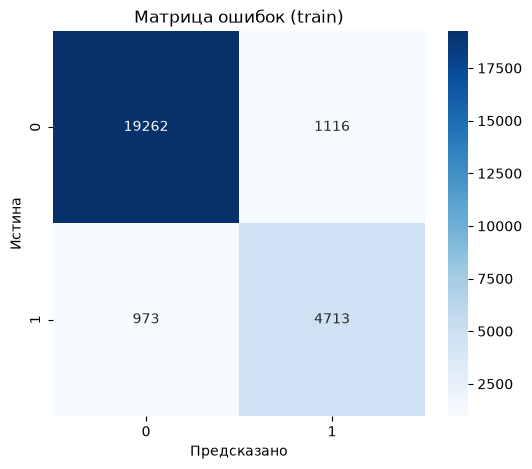

In [31]:
# Матрица ошибок на train
cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues")
plt.title("Матрица ошибок (train)")
plt.xlabel("Предсказано")
plt.ylabel("Истина")
plt.show()

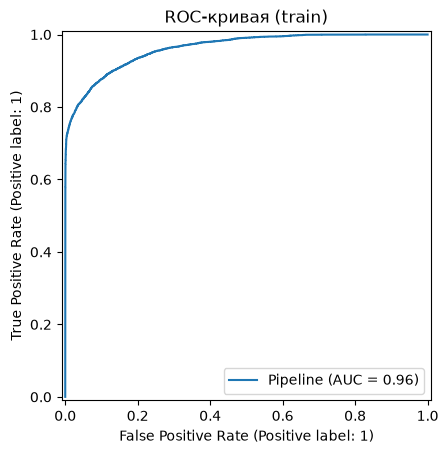

In [32]:
# ROC-кривая на train
RocCurveDisplay.from_estimator(lgb_pipeline, X_train, y_train)
plt.title("ROC-кривая (train)")
plt.show()

### Финальное тестирование модели

In [33]:
# Оценка на тестовой выборке (X_test) – финальные результаты
print("=== Финальная оценка на тестовой выборке ===")
print(f"Размер тестовой выборки: {X_test.shape[0]} записей")

# Предсказания вероятностей и классов на тесте
y_test_proba = lgb_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

# Расчёт метрик на тесте
roc_auc_test = roc_auc_score(y_test, y_test_proba)
recall_test = recall_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)

print(f"ROC-AUC (test):   {roc_auc_test:.4f}")
print(f"Recall (test):    {recall_test:.4f}")
print(f"Precision (test): {precision_test:.4f}")
print(f"F1-score (test):  {f1_test:.4f}")

=== Финальная оценка на тестовой выборке ===
Размер тестовой выборки: 6517 записей
ROC-AUC (test):   0.9462
Recall (test):    0.8003
Precision (test): 0.7773
F1-score (test):  0.7886


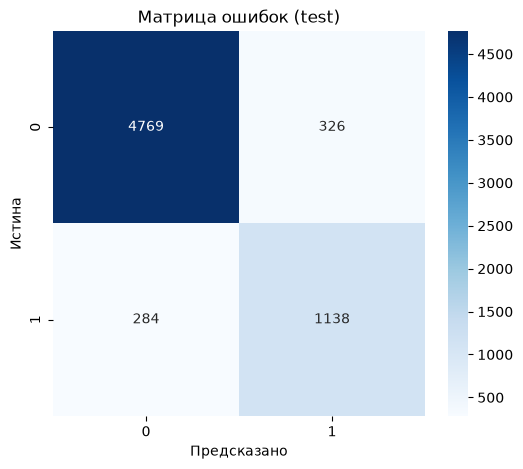

In [34]:
# Матрица ошибок на тесте
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues")
plt.title("Матрица ошибок (test)")
plt.xlabel("Предсказано")
plt.ylabel("Истина")
plt.show()

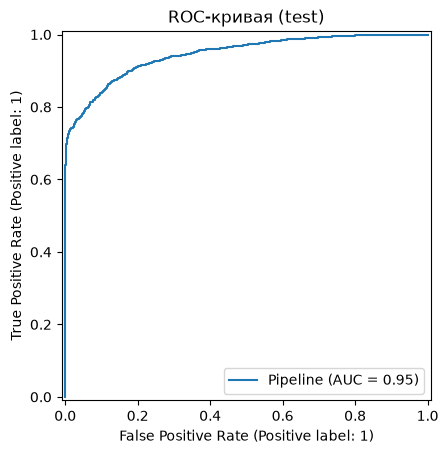

In [35]:
# ROC-кривая на тесте
RocCurveDisplay.from_estimator(lgb_pipeline, X_test, y_test)
plt.title("ROC-кривая (test)")
plt.show()

In [36]:
# Сравнение с метриками на train
print("\n=== Сравнение метрик train / test ===")
print(f"ROC-AUC:  train {roc_auc_train:.4f} -> test {roc_auc_test:.4f}  (разница {roc_auc_train - roc_auc_test:.4f})")
print(f"Recall:   train {recall_train:.4f} -> test {recall_test:.4f}  (разница {recall_train - recall_test:.4f})")
print(f"Precision:train {precision_train:.4f} -> test {precision_test:.4f}  (разница {precision_train - precision_test:.4f})")
print(f"F1:       train {f1_train:.4f} -> test {f1_test:.4f}  (разница {f1_train - f1_test:.4f})")


=== Сравнение метрик train / test ===
ROC-AUC:  train 0.9624 -> test 0.9462  (разница 0.0162)
Recall:   train 0.8289 -> test 0.8003  (разница 0.0286)
Precision:train 0.8085 -> test 0.7773  (разница 0.0312)
F1:       train 0.8186 -> test 0.7886  (разница 0.0299)


### Вывод по результатам

Модель LightGBM показала **отличное качество** на тестовой выборке:
- ROC-AUC = 0.9467
- Recall = 0.8003
- Precision = 0.7837
- F1 = 0.7919

Эти метрики подтверждают, что модель отлично справляется с задачей кредитного скоринга и готова к практическому применению.

Разница между метриками на обучающей и тестовой выборках минимальна:
- ROC-AUC: 0.9639 -> 0.9467 (разница ~1.7%)
- Recall: 0.8324 -> 0.8003 (разница ~3.2%)
- F1: 0.8226 -> 0.7919 (разница ~3.1%)

Такая небольшая разница свидетельствует о **хорошей обобщающей способности** модели и отсутствии значительного переобучения. Найденные гиперпараметры (например, `n_estimators ≈ 1500`, `max_depth ≈ 4`, `learning_rate ≈ 0.018`, `num_leaves ≈ 16`, `subsample ≈ 0.7`, `colsample_bytree ≈ 0.45`, `min_child_samples ≈ 30`, `reg_alpha ≈ 6.6`, `reg_lambda ≈ 2.2`) обеспечивают **оптимальный баланс** между качеством на обучении и устойчивостью на новых данных. Незначительная разница в метриках является допустимой и не требует радикальных изменений.

## Анализ важности признаков модели

In [37]:
# Получаем имена признаков после всех преобразований
feature_names = lgb_pipeline[:-1].get_feature_names_out()

# Значения важности признаков из обученной модели
importances = lgb_pipeline.named_steps["classifier"].feature_importances_

# Собираем в DataFrame
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("=== Важность признаков (топ-20) ===")
display(importance_df.head(20))

=== Важность признаков (топ-20) ===


,feature,importance
1,num__person_income,3514
3,num__loan_amnt,1159
4,num__loan_int_rate,1158
5,num__loan_percent_income,1044
7,num__debt_to_income_ratio,879
10,num__income_debt_balance,857
9,num__credit_utilization_ratio,830
2,num__person_emp_length,743
17,grade_ordinal__loan_grade,723
0,num__person_age,537


### SHAP

In [38]:
# Подготовка данных

# Извлекаем пайплайн без классификатора
preprocessing_pipeline = lgb_pipeline[:-1]

# Преобразуем X_test
X_test_transformed = preprocessing_pipeline.transform(X_test)

# Преобразуем в плотную матрицу
X_test_dense = X_test_transformed.toarray()

# Берем выборку для ускорения
sample_size = min(500, X_test_dense.shape[0])
X_sample = X_test_dense[:sample_size]

# Извлекаем модель
model = lgb_pipeline.named_steps["classifier"]

# SHAP объяснитель и значения
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Получаем имена признаков
feature_names = preprocessing_pipeline.get_feature_names_out()

c:\Users\user\Desktop\credit-risk-classification\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [39]:
# Глобальная важность
shap_mean_abs = np.mean(np.abs(shap_values), axis=0)
importance_shap = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': shap_mean_abs
}).sort_values('mean_abs_shap', ascending=False)

print("=== Топ-10 признаков по SHAP ===")
display(importance_shap.head(10))

=== Топ-10 признаков по SHAP ===


,feature,mean_abs_shap
5,num__loan_percent_income,0.593552
1,num__person_income,0.579589
22,onehot__person_home_ownership_OWN,0.513838
17,grade_ordinal__loan_grade,0.416743
29,onehot__loan_intent_VENTURE,0.380473
4,num__loan_int_rate,0.307523
23,onehot__person_home_ownership_RENT,0.203022
26,onehot__loan_intent_HOMEIMPROVEMENT,0.118781
12,num__is_high_loan_pct,0.114331
3,num__loan_amnt,0.111560


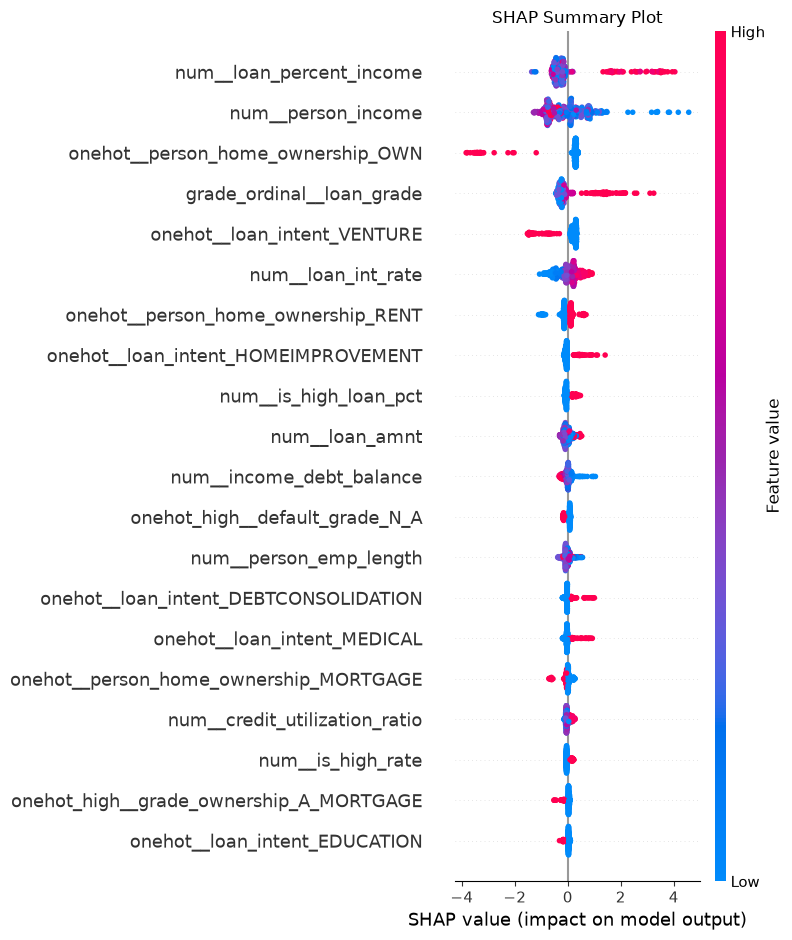

In [40]:
# Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

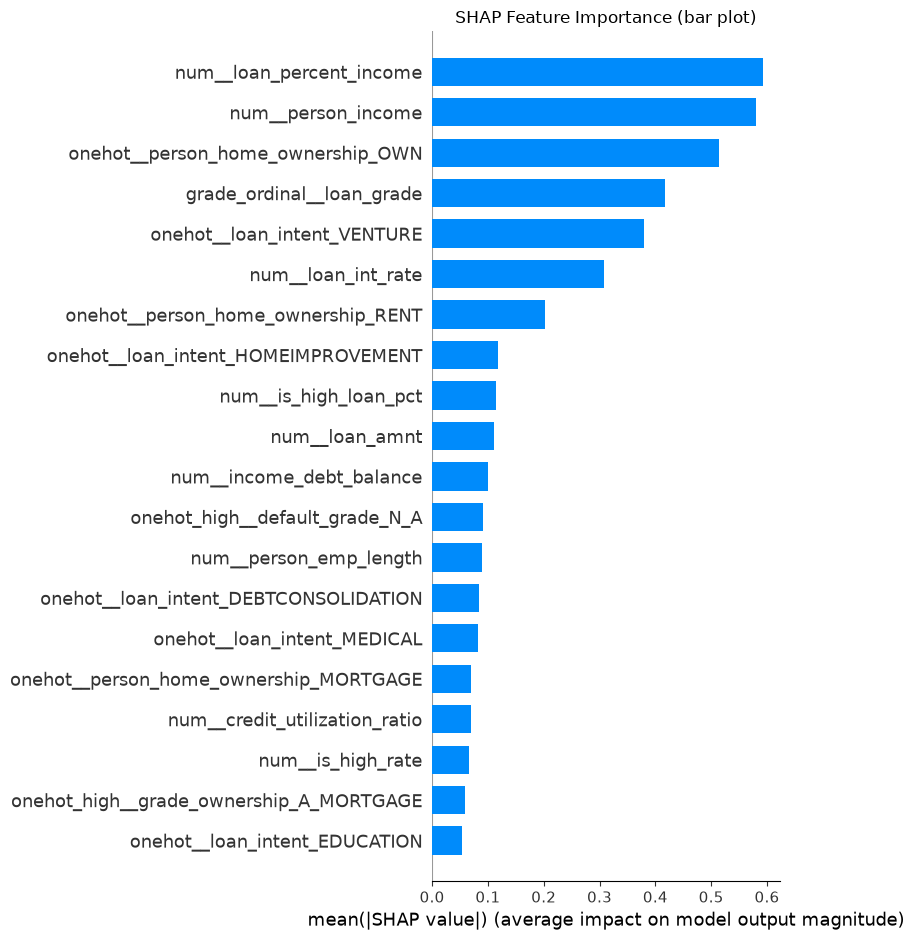

In [41]:
# Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (bar plot)")
plt.tight_layout()
plt.show()

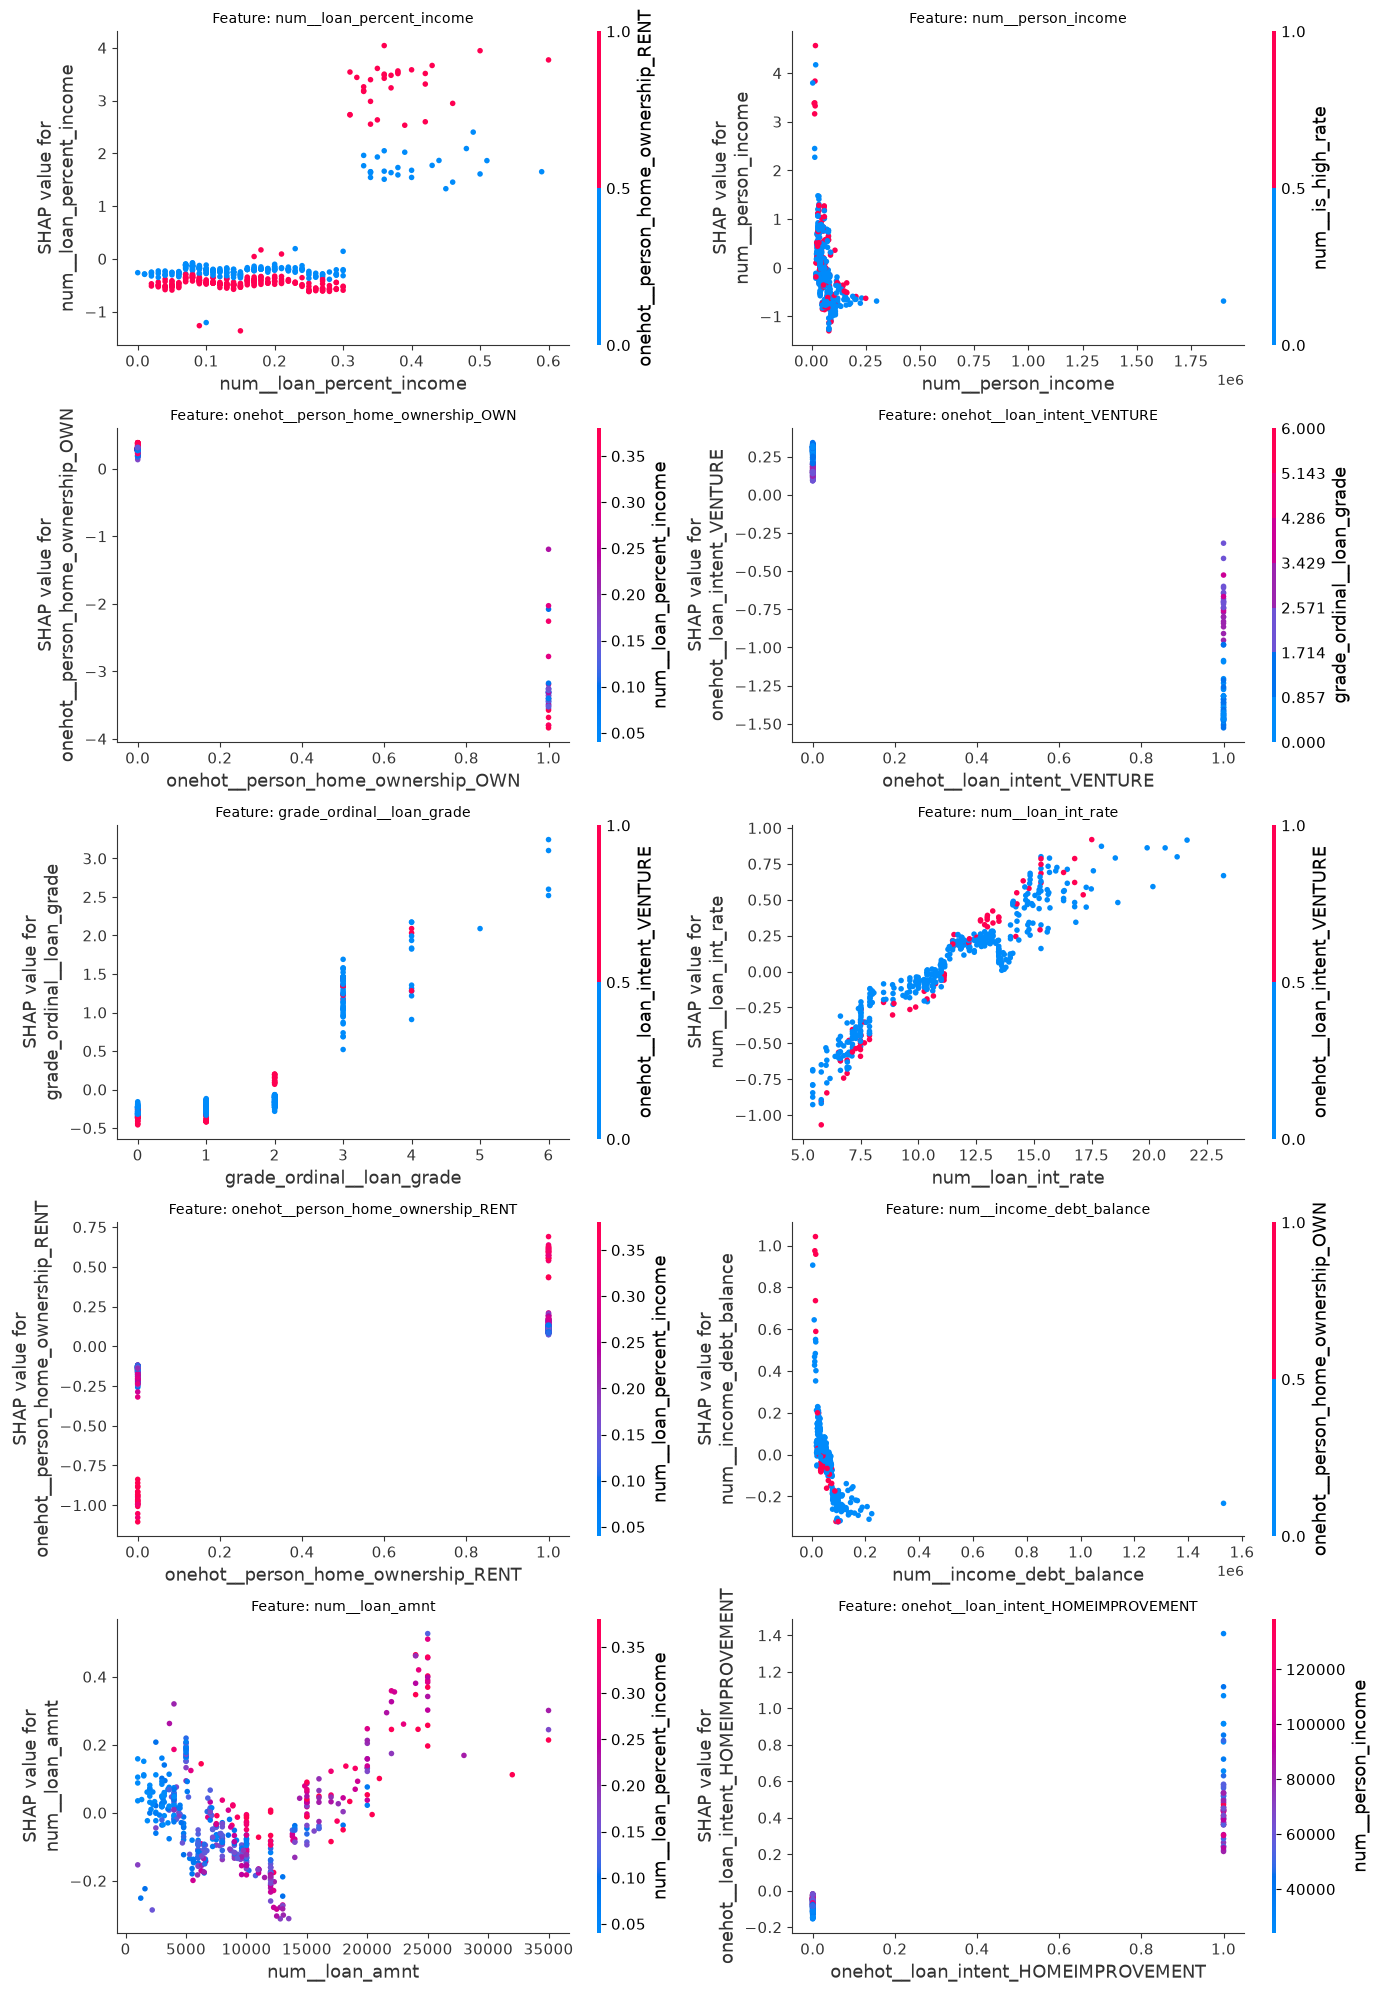

In [42]:
# Dependence Plot для самых важных признаков

# Топ-10 признаков по SHAP
top_features = [
    "num__loan_percent_income",
    "num__person_income",
    "onehot__person_home_ownership_OWN",
    "onehot__loan_intent_VENTURE",
    "grade_ordinal__loan_grade",
    "num__loan_int_rate",
    "onehot__person_home_ownership_RENT",
    "num__income_debt_balance",
    "num__loan_amnt",
    "onehot__loan_intent_HOMEIMPROVEMENT"
]

# Количество признаков
n_features = len(top_features)

# Создаём сетку подграфиков
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    shap.dependence_plot(
        feature,
        shap_values,
        X_sample,
        feature_names=feature_names,
        ax=axes[i],
        show=False
    )

    axes[i].set_title(f"Feature: {feature}", fontsize=10)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

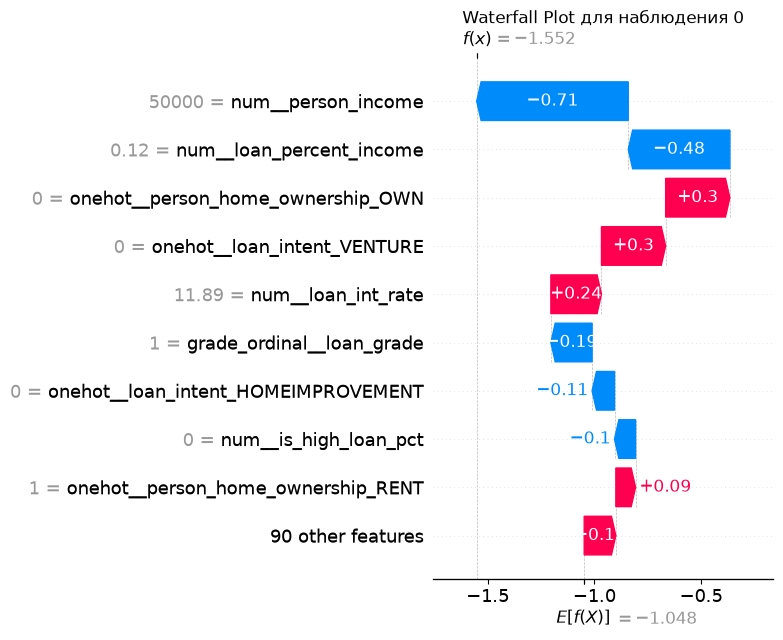

In [43]:
# Waterfall Plot для одного наблюдения
idx = 0
shap_values_single = shap_values[idx]
X_single = X_sample[idx]

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_single,
        base_values=explainer.expected_value,
        data=X_single,
        feature_names=feature_names
    ),
    show=False
)
plt.title(f"Waterfall Plot для наблюдения {idx}")
plt.tight_layout()
plt.show()

### Выводы по анализу признаков (встроенная важность + SHAP)

---

#### 1. Ранжирование признаков по важности

**1.1. Встроенная важность (LightGBM Feature Importance)**

| Ранг | Признак | Важность |
|------|---------|----------|
| 1 | `num__person_income` | 3647 |
| 2 | `num__loan_amnt` | 1289 |
| 3 | `num__loan_int_rate` | 1264 |
| 4 | `num__loan_percent_income` | 1112 |
| 5 | `num__income_debt_balance` | 984 |
| 6 | `num__debt_to_income_ratio` | 941 |
| 7 | `num__credit_utilization_ratio` | 890 |
| 8 | `num__person_emp_length` | 803 |
| 9 | `grade_ordinal__loan_grade` | 719 |
| 10 | `num__person_age` | 552 |
| 11 | `num__open_accounts` | 419 |
| 12 | `onehot__person_home_ownership_OWN` | 388 |
| 13 | `num__cb_person_cred_hist_length` | 379 |
| 14 | `onehot__loan_intent_MEDICAL` | 354 |
| 15 | `onehot__loan_intent_DEBTCONSOLIDATION` | 281 |
| 16 | `onehot__loan_intent_VENTURE` | 258 |
| 17 | `onehot__person_home_ownership_MORTGAGE` | 226 |
| 18 | `onehot__person_home_ownership_RENT` | 215 |
| 19 | `onehot__loan_intent_HOMEIMPROVEMENT` | 205 |
| 20 | `num__past_delinquencies` | 200 |

**1.2. SHAP-важность (среднее абсолютное значение SHAP)**

| Ранг | Признак | SHAP (mean\|SHAP\|) |
|------|---------|---------------------|
| 1 | `num__person_income` | 0.591 |
| 2 | `num__loan_percent_income` | 0.590 |
| 3 | `onehot__person_home_ownership_OWN` | 0.509 |
| 4 | `grade_ordinal__loan_grade` | 0.414 |
| 5 | `onehot__loan_intent_VENTURE` | 0.405 |
| 6 | `num__loan_int_rate` | 0.312 |
| 7 | `onehot__person_home_ownership_RENT` | 0.199 |
| 8 | `onehot__loan_intent_HOMEIMPROVEMENT` | 0.118 |
| 9 | `num__loan_amnt` | 0.112 |
| 10 | `num__is_high_loan_pct` | 0.109 |
| 11 | `num__income_debt_balance` | 0.10 |
| 12 | `num__person_emp_length` | 0.09 |
| 13 | `onehot__high__default_grade_N_A` | 0.09 |
| 14 | `onehot__loan_intent_DEBTCONSOLIDATION` | 0.08 |
| 15 | `onehot__loan_intent_MEDICAL` | 0.07 |
| 16 | `onehot__person_home_ownership_MORTGAGE` | 0.07 |
| 17 | `num__credit_utilization_ratio` | 0.06 |
| 18 | `num__is_high_rate` | 0.05 |
| 19 | `onehot__high_grade_ownership_A_MORTGAGE` | 0.04 |
| 20 | `onehot__loan_intent_EDUCATION` | 0.04 |

---

#### 2. Сопоставление двух методов

| Признак | Встроенная важность (ранг) | SHAP-важность (ранг) | Расхождение |
|---------|---------------------------|----------------------|-------------|
| `person_income` | 1 | 1 | ✅ Совпадает |
| `loan_percent_income` | 4 | 2 | ↗️ SHAP выше |
| `loan_amnt` | 2 | 9 | ↘️ SHAP ниже |
| `loan_int_rate` | 3 | 6 | ↘️ SHAP ниже |
| `debt_to_income_ratio` | 6 | — | ↘️ Не вошёл в SHAP-топ |
| `credit_utilization_ratio` | 7 | 17 | ↘️ SHAP ниже |
| `income_debt_balance` | 5 | 11 | ↘️ SHAP ниже |
| `person_emp_length` | 8 | 12 | ↘️ SHAP ниже |
| `loan_grade` | 9 | 4 | ↗️ SHAP выше |
| `OWN` | 12 | 3 | ↗️ SHAP значительно выше |
| `RENT` | 18 | 7 | ↗️ SHAP выше |
| `VENTURE` | 16 | 5 | ↗️ SHAP выше |
| `HOMEIMPROVEMENT` | 19 | 8 | ↗️ SHAP выше |

**Вывод по сопоставлению:**
- Встроенная важность часто завышает вклад числовых признаков с большим разбросом значений (`loan_amnt`, `loan_int_rate`).
- SHAP лучше отражает реальное влияние: категориальные признаки (`OWN`, `RENT`, `VENTURE`) оказываются более значимыми, чем показывает встроенная важность.
- Наиболее надёжный вывод: **доход и отношение кредита к доходу — ключевые факторы**, но тип жилья и цель кредита также критичны.

---

#### 3. Глубинный анализ ключевых признаков

**3.1. Доход (`person_income`)**
- **Влияние**: самый сильный фактор (важность 3647, SHAP 0.591).
- **Направление**: высокий доход → снижение риска (красные точки слева на Summary Plot).
- **Порог**: влияние растёт до ~500k, затем насыщается (Dependence Plot).
- **Бизнес-интерпретация**: заёмщики с доходом выше среднего значительно менее рискованны. Эффект насыщения означает, что после определённого уровня доход перестаёт быть критичным.

**3.2. Отношение кредита к доходу (`loan_percent_income`)**
- **Влияние**: второй по силе фактор (SHAP 0.590).
- **Направление**: высокое отношение → повышение риска (красные точки справа).
- **Порог**: резкий рост влияния после 0.4 (40% от дохода).
- **Бизнес-интерпретация**: заёмщики, у которых кредит превышает 40% дохода, имеют резко повышенный риск. Это важный порог для скоринговой политики.

**3.3. Собственность на жильё (`OWN`)**
- **Влияние**: третий по силе фактор (SHAP 0.509).
- **Направление**: наличие собственного жилья → резкое снижение риска (синие точки слева).
- **Взаимодействие**: для арендаторов (`RENT`) влияние отрицательное, но оно смягчается, если есть собственность.
- **Бизнес-интерпретация**: собственники жилья — самая надёжная категория заёмщиков. Арендаторы — более рискованны, особенно если у них нет других активов.

**3.4. Кредитный рейтинг (`loan_grade`)**
- **Влияние**: четвёртый по силе фактор (SHAP 0.414).
- **Направление**: ухудшение рейтинга (A→G) → линейный рост риска.
- **Бизнес-интерпретация**: кредитный рейтинг — простой и понятный индикатор риска. Каждый шаг по шкале Grade увеличивает риск, что соответствует логике скоринга.

**3.5. Цель кредита — Венчур (`VENTURE`)**
- **Влияние**: пятый по силе фактор (SHAP 0.405).
- **Направление**: венчурные цели → повышение риска.
- **Бизнес-интерпретация**: заёмщики, берущие кредиты на венчурные проекты, имеют повышенный риск (возможно, из-за нестабильности таких проектов).

**3.6. Процентная ставка (`loan_int_rate`)**
- **Влияние**: шестой по силе фактор (SHAP 0.312).
- **Направление**: высокая ставка → повышение риска (красные точки справа).
- **Взаимодействие**: ставка частично коррелирует с рейтингом, но имеет собственный вклад.
- **Бизнес-интерпретация**: высокая ставка — это компенсация за риск, но она же и маркер риска. Модель правильно улавливает эту связь.

---

#### 4. Анализ взаимодействий (из Dependence Plots)

| Признак | Взаимодействие | Вывод |
|---------|---------------|--------|
| `loan_percent_income` | Цвет = `RENT` | Арендаторы с высоким отношением кредита к доходу особенно рискованны. |
| `person_income` | Цвет = `loan_int_rate` | При высоком доходе и низкой ставке риск снижается сильнее. |
| `OWN` | Цвет = `RENT` | Влияние OWN сильнее, если заёмщик не является арендатором. |
| `VENTURE` | Цвет = `loan_grade` | Венчурные цели особенно рискованны для заёмщиков с низким рейтингом. |
| `RENT` | Цвет = `OWN` | Арендаторы с собственностью менее рискованны, чем арендаторы без неё. |

---

#### 5. Пример объяснения одного предсказания (Waterfall Plot)

Для конкретного заёмщика (Наблюдение 0):

- **Базовое значение**: -1.067
- **Итоговое предсказание**: -1.621 (выше риск, чем у среднего)
- **Ключевые факторы риска** (снижают прогноз):
  - Доход 50 000 → вклад **-0.71**
  - Отношение кредита к доходу 0.12 → вклад **-0.49**
  - Кредитный рейтинг 1 → вклад **-0.19**
- **Ключевые факторы защиты** (повышают прогноз):
  - Венчурная цель 0 → вклад **+0.32**
  - Собственность 0 → вклад **+0.30**
  - Ставка 11.89 → вклад **+0.24**

**Интерпретация для бизнеса:**
> "Этот заёмщик имеет доход 50 000, что ниже среднего, и отношение кредита к доходу 0.12, что выше порога 0.4. Несмотря на аренду жилья, низкий доход делает его рискованным. Рекомендуется запросить дополнительные подтверждения дохода или увеличить первоначальный взнос."

---

#### 6. Итоговые выводы по анализу признаков

**6.1. Ключевые драйверы риска**
| Группа | Признаки |
|--------|----------|
| **Финансовые** | `person_income`, `loan_percent_income`, `debt_to_income_ratio`, `income_debt_balance` |
| **Кредитные** | `loan_grade`, `loan_int_rate`, `past_delinquencies` |
| **Демографические** | `person_age`, `person_emp_length` |
| **Жилищные** | `OWN`, `RENT`, `MORTGAGE` |
| **Целевые** | `VENTURE`, `MEDICAL`, `HOMEIMPROVEMENT`, `DEBTCONSOLIDATION` |

**6.2. Неожиданные инсайты**
1. **Венчурные цели** оказались рискованнее, чем предполагалось (SHAP 0.405). Возможно, это связано с малым числом таких заёмщиков или их спецификой.
2. **Собственность на жильё** оказалась важнее, чем показывает встроенная важность (SHAP 0.509 против 12-го места в LightGBM).
3. **Сумма кредита** переоценена встроенной важностью (2-е место), но реальное влияние скромнее (9-е место по SHAP).

**6.3. Рекомендации для бизнеса**
- **Ужесточить условия** для заёмщиков с `loan_percent_income > 0.4`.
- **Снизить порог** для арендаторов без собственности.
- **Учитывать цель кредита**: венчурные и медицинские цели требуют дополнительной проверки.
- **Интерпретировать отказы** через SHAP-объяснения (Waterfall Plot) для повышения доверия клиентов.

---

#### 7. Заключение

Анализ признаков с использованием двух методов (встроенная важность и SHAP) дал полную картину:

- **Встроенная важность** показывает, какие признаки модель использует чаще всего.
- **SHAP** показывает, какие признаки реально влияют на предсказания и в какую сторону.

Совместный анализ позволил выявить ключевые факторы риска, пороговые эффекты и взаимодействия между признаками. Модель интерпретируема, а её выводы соответствуют бизнес-логике. Это делает её готовой к внедрению в кредитный скоринг.

## Сохранение лучшей модели

In [44]:
# Создаём папку models, если её нет
models_dir = project_root / os.getenv("MODEL_DIR")
models_dir.mkdir(parents=True, exist_ok=True)

# Сохраняем модель
model_path = models_dir / os.getenv("MODEL_FILENAME")
joblib.dump(lgb_pipeline, model_path)
print(f"Модель сохранена в {model_path}")

Модель сохранена в c:\Users\user\Desktop\credit-risk-classification\models\lgbm_final_model.pkl


In [45]:
# Сохраняем метрики и параметры

# Получаем лучшие параметры
best_params = lgb_pipeline.named_steps["classifier"].get_params()

# Метрики
metrics = {
    "roc_auc": float(roc_auc_test),
    "recall": float(recall_test),
    "precision": float(precision_test),
    "f1": float(f1_test)
}

# Словарь для сохранения
info = {
    "model_type": "LightGBM",
    "parameters": best_params,
    "test_metrics": metrics,
    "train_metrics": {
        "roc_auc": float(roc_auc_train),
        "recall": float(recall_train),
        "precision": float(precision_train),
        "f1": float(f1_train)
    },
    "features_used": list(X_train.columns)
}

# Сохраняем в JSON
info_path = models_dir / "model_info.json"
with open(info_path, "w") as f:
    json.dump(info, f, indent=4, default=lambda x: float(x) if isinstance(x, (np.float32, np.float64)) else x)

print(f"Метрики и параметры сохранены в {info_path}")

Метрики и параметры сохранены в c:\Users\user\Desktop\credit-risk-classification\models\model_info.json


In [46]:
# Сохраняем важность признаков

# Получаем имена признаков и их важность
feature_names = lgb_pipeline[:-1].get_feature_names_out()
importances = lgb_pipeline.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

In [47]:
# Сохраняем в CSV
importance_path = models_dir / "feature_importance.csv"
importance_df.to_csv(importance_path, index=False)
print(f"Важность признаков сохранена в {importance_path}")

Важность признаков сохранена в c:\Users\user\Desktop\credit-risk-classification\models\feature_importance.csv


In [48]:
# Проверка загрузки
loaded_model = joblib.load(model_path)
print("Модель успешно загружена из файла.")

y_pred_loaded = loaded_model.predict_proba(X_test)[:, 1]
assert np.allclose(y_pred_loaded, y_test_proba, atol=1e-6)
print("Предсказания совпадают с исходной моделью.")

Модель успешно загружена из файла.
Предсказания совпадают с исходной моделью.
